In [1]:
import os
import glob
import json
import h5py
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as cl
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
import pandas as pd
from collections import defaultdict
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    f1_score,
    cohen_kappa_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
)

In [2]:
def safe_cw_auc(targets, scores, mode = 'ovo', count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)
    unique_targets = unique_targets[counts > count_lim]
    cw_auc = np.full(scores.shape[-1], np.nan)
    if len(unique_targets) == 1:
        return cw_auc
    for k in unique_targets:
        if mode == 'ovo':
            cw_auc[k] = 0
            for l in unique_targets:
                if l == k: continue
                tmp_mask = np.logical_or(targets == k, targets == l)
                tmp_targets = targets[tmp_mask]
                tmp_scores = scores[tmp_mask, k]
                cw_auc_kvl = roc_auc_score(tmp_targets == k,tmp_scores)
                cw_auc[k] += cw_auc_kvl/(len(unique_targets -1))
        elif mode == 'ovr':
            cw_auc[k] = roc_auc_score(targets == k, scores[:, k])
        else:
            raise "Mode must be ovo or ovr"
    return cw_auc

def safe_cw_pr_re_f1(targets, preds, num_classes, count_lim = 2):
    unique_targets, counts = np.unique(targets, return_counts=True)

    # Target count filter
    count_filt = np.full(num_classes, np.nan)
    count_filt[unique_targets[counts > count_lim]] = 1 

    # Calculate scores (results will only include present targets)
    cw_prec = precision_score(targets, preds, average=None, zero_division=np.nan)
    cw_rec = recall_score(targets, preds, average=None, zero_division=np.nan)
    cw_f1 = f1_score(targets, preds, average=None, zero_division=np.nan)

    # Initialize NaN arrays to fill to make sure all possible targets are representet
    cw_prec_array = np.full(num_classes, np.nan)
    cw_rec_array = np.full(num_classes, np.nan)
    cw_f1_array = np.full(num_classes, np.nan)

    # Fill in NaN arrays
    for i, k in enumerate(unique_targets):
        cw_prec_array[k] = cw_prec[i] * count_filt[i]
        cw_rec_array[k] = cw_rec[i] * count_filt[i]
        cw_f1_array[k] = cw_f1[i] * count_filt[i]

    return cw_prec_array, cw_rec_array, cw_f1_array

def calc_sleep_summary_metrics(stages, label_map):
    metrics = {}
    # Calculate TST
    sleep = stages != label_map['wake']
    tst = (sleep).sum()
    metrics['tst'] = float(tst)
    
    try:
        # Calculate SOL (first consecutive 3-epoch sleep window)
        # [[sleep, False, False],
        # [False, sleep, False],
        # [False, False, sleep]]
        sleep_shifted = np.stack([
            np.append(sleep, [False, False]),
            np.insert(np.append(sleep, [False]), 0, [False]),
            np.insert(sleep, 0, [False, False]),
        ])
        sol = np.argwhere(sleep_shifted.all(axis=0)).min()
        metrics['sol'] = float(sol)

        # Calculate WASO, how to handle missing?
        # Trim back from the last index if it is wake
        # Find last index of sleep 
        last_sleep = np.argwhere(stages != label_map['wake']).max() + 1
        waso = (stages[sol: last_sleep] == label_map['wake']).sum()
        metrics['waso'] = float(waso)
    except:
        metrics['sol'] = np.nan
        metrics['waso'] = np.nan
    # Calculate SE
    # se = (stages[sol: last_sleep] != label_map['wake']).sum() / (last_sleep - sol)
    se = (stages != label_map['wake']).sum() / len(stages)
    metrics['se'] = float(se)

    # Calculate REM
    rem = (stages == ss_label_map['rem']).sum()
    metrics['rem'] = float(rem)
    
    # Calculate Deep
    deep = (stages == ss_label_map['deep']).sum()
    metrics['deep'] = float(deep)

    # Calculate Light
    light = (stages == ss_label_map['light']).sum()
    metrics['light'] = float(light)

    # Calculate NREM
    nrem = light + deep
    metrics['nrem'] = float(nrem)

    return metrics

In [3]:
ss_labels_name = 'light_deep_rem'
ss_label_map = {
    'deep': 0,
    'light': 1,
    'rem': 2,
    'wake': 3,
    'missing': -9,
}
# ss_label_map_inv = {val: key for key, val in ss_label_map.items()}
ss_label_map_inv = {val: key for key, val in ss_label_map.items() if val != -9}
ss_label_order = ['wake', 'light', 'deep', 'rem']
ss_label_name = ['Wake', 'Light', 'Deep', 'REM']

ss_colormap = {
    'wake': 'tab:red',
    'Wake': 'tab:red',
    'light': 'tab:orange',
    'Light': 'tab:orange',
    'deep': 'tab:blue',
    'Deep': 'tab:blue',
    'rem': 'tab:green',
    'REM': 'tab:green',
}
ss_case_map = {
    'wake':'Wake',
    'light': 'Light',
    'deep': 'Deep',
    'rem': 'REM',
}

dset_map = {
    'newcastle_left': 'Newcastle L',
    'newcastle_right': 'Newcastle R',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
}
dset_order = ['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']

In [74]:
## Subject-wise performance metrics
cw_precs = defaultdict(list)
cw_recalls = defaultdict(list)
cw_f1s = defaultdict(list)

cw_aucs = defaultdict(list)
roc_curves = defaultdict(list)
soft_preds_all = []
targets_all = []

macro_results = defaultdict(list)
summary_diffs = defaultdict(list)
summary_means = defaultdict(list)
exp_i = []
subject_i = []
dataset_i = []
exp1_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_tp/tp_1.0/'
exp2_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_internal/'
exp3_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_tp/tp_1.0/'
exp4_path = '/oak/stanford/groups/mignot/projects/actigraphy_fm/results/bwm_mae_lstmc_internal/'
experiments = [('Linear, TBI Only', exp1_path), ('Linear, Full Internal', exp2_path), ('LSTM-C, TBI Only', exp3_path), ('LSTM-C, Full Internal', exp4_path)]
for exp_name, experiment_dir in experiments:
    for dataset in os.scandir(experiment_dir):
        for sub_dir in os.scandir(dataset):
            subject_i.append(os.path.basename(sub_dir))
            dataset_i.append(os.path.basename(dataset))
            exp_i.append(exp_name)

            missing_idx = ss_label_map['missing']

            scores = np.load(os.path.join(sub_dir.path + '/soft_preds.npy'))
            targets = np.load(os.path.join(sub_dir.path + '/targets.npy'))

            scores = scores[targets != missing_idx]
            targets = targets[targets != missing_idx]
            
            soft_preds_all.append(scores)
            targets_all.append(targets)
            
            # Get hard predictions
            preds = scores.argmax(axis=-1)

            unique_targets, counts = np.unique(targets, return_counts=True)
            unique_preds, pred_counts = np.unique(preds, return_counts=True)

            ## Subject-wise class-wise scores
            # Precision, Recall, and F1
            cw_pr, cw_re, cw_f1 = safe_cw_pr_re_f1(targets, preds, num_classes=scores.shape[-1], count_lim=3)
            
            # Manually compute binary AUC for each label present (NaN for non-valid)
            cw_auc = safe_cw_auc(targets, scores, mode='ovr', count_lim=3)

            for k in range(scores.shape[-1]):
                cw_aucs[ss_label_map_inv[k]].append(float(cw_auc[k]))
                cw_precs[ss_label_map_inv[k]].append(float(cw_pr[k]))
                cw_recalls[ss_label_map_inv[k]].append(float(cw_re[k]))
                cw_f1s[ss_label_map_inv[k]].append(float(cw_f1[k]))

            # Class-wise ROC curves
            for k in unique_targets:
                roc = roc_curve(targets, scores[:,k], pos_label=k)
                roc_curves[ss_label_map_inv[k]].append(roc)
            
            ## Subject-wise macro averages
            mac_prec = precision_score(targets, preds, average='macro', zero_division=np.nan)
            mac_rec = recall_score(targets, preds, average='macro', zero_division=np.nan)
            mac_f1 = f1_score(targets, preds, average='macro', zero_division=np.nan)
            kappa = cohen_kappa_score(targets, preds)
            macro_results['Precision'].append(mac_prec)
            macro_results['Recall'].append(mac_rec)
            macro_results['F1'].append(mac_f1)
            macro_results['Kappa'].append(kappa)
            macro_results['AUROC'].append(np.nanmean(cw_auc))

            pred_metrics = calc_sleep_summary_metrics(preds, ss_label_map)
            target_metrics = calc_sleep_summary_metrics(targets, ss_label_map)
            summary_diff = {
                f'{key}': pred_metrics[key] - target_metrics[key]
                for key
                in pred_metrics.keys()
            }
            summary_mean = {
                f'{key}': (pred_metrics[key] + target_metrics[key])/2 
                for key 
                in pred_metrics.keys()
            }
            for key in summary_diff.keys():
                summary_diffs[key].append(summary_diff[key])
                summary_means[key].append(summary_mean[key])
            

macro_results = pd.DataFrame(data=macro_results)
cw_aucs = pd.DataFrame(data=cw_aucs)
cw_precs = pd.DataFrame(data=cw_precs)
cw_recalls = pd.DataFrame(data=cw_recalls)
cw_f1s = pd.DataFrame(data=cw_f1s)
summary_means = pd.DataFrame(data=summary_means)
summary_diffs = pd.DataFrame(data=summary_diffs)
for col in summary_means.columns:
    if col == 'se':
        factor = 100 # fraction to %
    else:
        factor = 0.5 # 30s epoch to minutes
    summary_diffs[col] = summary_diffs[col] * factor
    summary_means[col] = summary_means[col] * factor

soft_preds_all = np.concatenate(soft_preds_all)
targets_all = np.concatenate(targets_all)
preds_all = soft_preds_all.argmax(axis=-1)

In [6]:
## Macro TABLE
macro_table = macro_results.copy()
macro_table['dataset'] = dataset_i
macro_table['finetuning'] = exp_i
macro_table['dataset'] = macro_table['dataset'].map({
    'newcastle_left': 'Newcastle L',
    'newcastle_right': 'Newcastle R',
    'stages': 'STAGES',
    'dreamt': 'DREAMT',
    'tbi': 'TBI',
})
sd_df = macro_table.groupby(['dataset','finetuning']).std()
mean_df = macro_table.groupby(['dataset','finetuning']).mean()
macro_table = mean_df.round(3).astype(str) + " ± " + sd_df.round(3).astype(str)
macro_table
# new_df.to_csv('/oak/stanford/groups/mignot/projects/actigraphy_fm/results/tp_macro_results.csv')
# new_df

Precision         Recall  \
dataset     finetuning                                            
DREAMT      LSTM-C, Full Internal  0.462 ± 0.102  0.572 ± 0.139   
            LSTM-C, TBI Only       0.443 ± 0.107  0.548 ± 0.136   
            Linear, Full Internal    0.451 ± 0.1  0.564 ± 0.144   
            Linear, TBI Only       0.427 ± 0.088  0.547 ± 0.137   
Newcastle L LSTM-C, Full Internal  0.495 ± 0.137  0.521 ± 0.134   
            LSTM-C, TBI Only       0.464 ± 0.148   0.494 ± 0.13   
            Linear, Full Internal  0.439 ± 0.118  0.466 ± 0.117   
            Linear, TBI Only       0.442 ± 0.115  0.458 ± 0.115   
Newcastle R LSTM-C, Full Internal  0.499 ± 0.115  0.503 ± 0.142   
            LSTM-C, TBI Only       0.481 ± 0.116  0.494 ± 0.119   
            Linear, Full Internal  0.486 ± 0.149  0.462 ± 0.147   
            Linear, TBI Only       0.491 ± 0.147  0.457 ± 0.141   
STAGES      LSTM-C, Full Internal   0.508 ± 0.08  0.545 ± 0.106   
            LSTM-C, TBI Only       0.522 ± 0.119  0.476 ± 0.118   
            Linear, Full Internal  0.491 ± 0.076  0.518 ± 0.076   
            Linear, TBI Only        0.47 ± 0.073   0.509 ± 0.08   
TBI         LSTM-C, Full Internal  0.515 ± 0.131   0.535 ± 0.14   
            LSTM-C, TBI Only       0.523 ± 0.124   0.55 ± 0.135   
            Linear, Full Internal  0.505 ± 0.106  0.538 ± 0.132   
            Linear, TBI Only       0.512 ± 0.109  0.538 ± 0.134   

                                              F1          Kappa            AUC  
dataset     finetuning                                                          
DREAMT      LSTM-C, Full Internal   0.41 ± 0.118  0.286 ± 0.155    0.8 ± 0.107  
            LSTM-C, TBI Only        0.366 ± 0.11  0.234 ± 0.128  0.794 ± 0.101  
            Linear, Full Internal  0.413 ± 0.116  0.305 ± 0.167  0.792 ± 0.103  
            Linear, TBI Only       0.367 ± 0.107  0.241 ± 0.139    0.782 ± 0.1  
Newcastle L LSTM-C, Full Internal   0.454 ± 0.14  0.304 ± 0.165    0.754 ± 0.1  
            LSTM-C, TBI Only         0.4 ± 0.121  0.241 ± 0.143  0.727 ± 0.094  
            Linear, Full Internal    0.4 ± 0.114  0.226 ± 0.126  0.709 ± 0.104  
            Linear, TBI Only       0.399 ± 0.111  0.222 ± 0.122  0.698 ± 0.105  
Newcastle R LSTM-C, Full Internal  0.443 ± 0.126  0.275 ± 0.146  0.741 ± 0.127  
            LSTM-C, TBI Only       0.413 ± 0.106  0.254 ± 0.122  0.726 ± 0.115  
            Linear, Full Internal   0.403 ± 0.13  0.225 ± 0.144  0.715 ± 0.124  
            Linear, TBI Only       0.409 ± 0.129  0.228 ± 0.142  0.712 ± 0.123  
STAGES      LSTM-C, Full Internal  0.465 ± 0.104   0.33 ± 0.132  0.801 ± 0.091  
            LSTM-C, TBI Only       0.356 ± 0.103  0.246 ± 0.118  0.761 ± 0.087  
            Linear, Full Internal   0.47 ± 0.083   0.334 ± 0.11  0.782 ± 0.067  
            Linear, TBI Only       0.425 ± 0.082  0.284 ± 0.105  0.763 ± 0.066  
TBI         LSTM-C, Full Internal  0.447 ± 0.149  0.306 ± 0.166  0.796 ± 0.114  
            LSTM-C, TBI Only        0.46 ± 0.139  0.328 ± 0.161  0.796 ± 0.111  
            Linear, Full Internal  0.443 ± 0.142  0.307 ± 0.166  0.785 ± 0.107  
            Linear, TBI Only        0.45 ± 0.136  0.309 ± 0.162  0.784 ± 0.104

In [49]:
macro_new.drop(columns=['dataset']).melt(
    id_vars=['finetuning']
).groupby(
    ['finetuning','variable']
).mean().swaplevel(
    'variable','finetuning'
).sort_values(
    ['variable']
)
# ).sort_values(
#     ['variable', 'dataset']
# ).reset_index(
#     'dataset'
# ).drop(columns=['dataset']).groupby(['variable','finetuning']).mean()

value
variable  finetuning                     
AUROC     LSTM-C, Full Internal  0.788596
          LSTM-C, TBI Only       0.777108
          Linear, Full Internal  0.772816
          Linear, TBI Only       0.764804
F1        LSTM-C, Full Internal  0.435429
          LSTM-C, TBI Only       0.400939
          Linear, Full Internal  0.426944
          Linear, TBI Only       0.406343
Kappa     LSTM-C, Full Internal  0.297915
          Linear, TBI Only       0.263527
          LSTM-C, TBI Only       0.266461
          Linear, Full Internal  0.293487
Precision LSTM-C, Full Internal  0.490278
          LSTM-C, TBI Only       0.482467
          Linear, TBI Only       0.465322
          Linear, Full Internal  0.474378
Recall    LSTM-C, TBI Only       0.528970
          LSTM-C, Full Internal  0.545534
          Linear, Full Internal  0.530522
          Linear, TBI Only       0.521905

In [47]:
macro_new.melt(
    id_vars=['dataset','finetuning']
).groupby(
    ['dataset','finetuning','variable']
).mean(
).swaplevel(
    'variable','dataset'
).sort_values(
    ['variable', 'dataset']
).reset_index(
    'dataset'
).drop(columns=['dataset']).groupby(['variable','finetuning']).mean()

value
variable  finetuning                     
AUROC     LSTM-C, Full Internal  0.778485
          LSTM-C, TBI Only       0.760754
          Linear, Full Internal  0.756603
          Linear, TBI Only       0.747781
F1        LSTM-C, Full Internal  0.443869
          LSTM-C, TBI Only       0.398945
          Linear, Full Internal  0.426072
          Linear, TBI Only       0.409911
Kappa     LSTM-C, Full Internal  0.300028
          LSTM-C, TBI Only       0.260717
          Linear, Full Internal  0.279483
          Linear, TBI Only       0.256776
Precision LSTM-C, Full Internal  0.495616
          LSTM-C, TBI Only       0.486478
          Linear, Full Internal  0.474441
          Linear, TBI Only       0.468235
Recall    LSTM-C, Full Internal  0.535132
          LSTM-C, TBI Only       0.512247
          Linear, Full Internal  0.509441
          Linear, TBI Only       0.501746

subject
mecsleep60_left     True
mecsleep14_left     True
mecsleep49_left     True
mecsleep42_left     True
mecsleep34_left     True
                   ...  
21-02451           False
06-01193           False
07-07230           False
21-02430           False
18-01129           False
Length: 312, dtype: bool

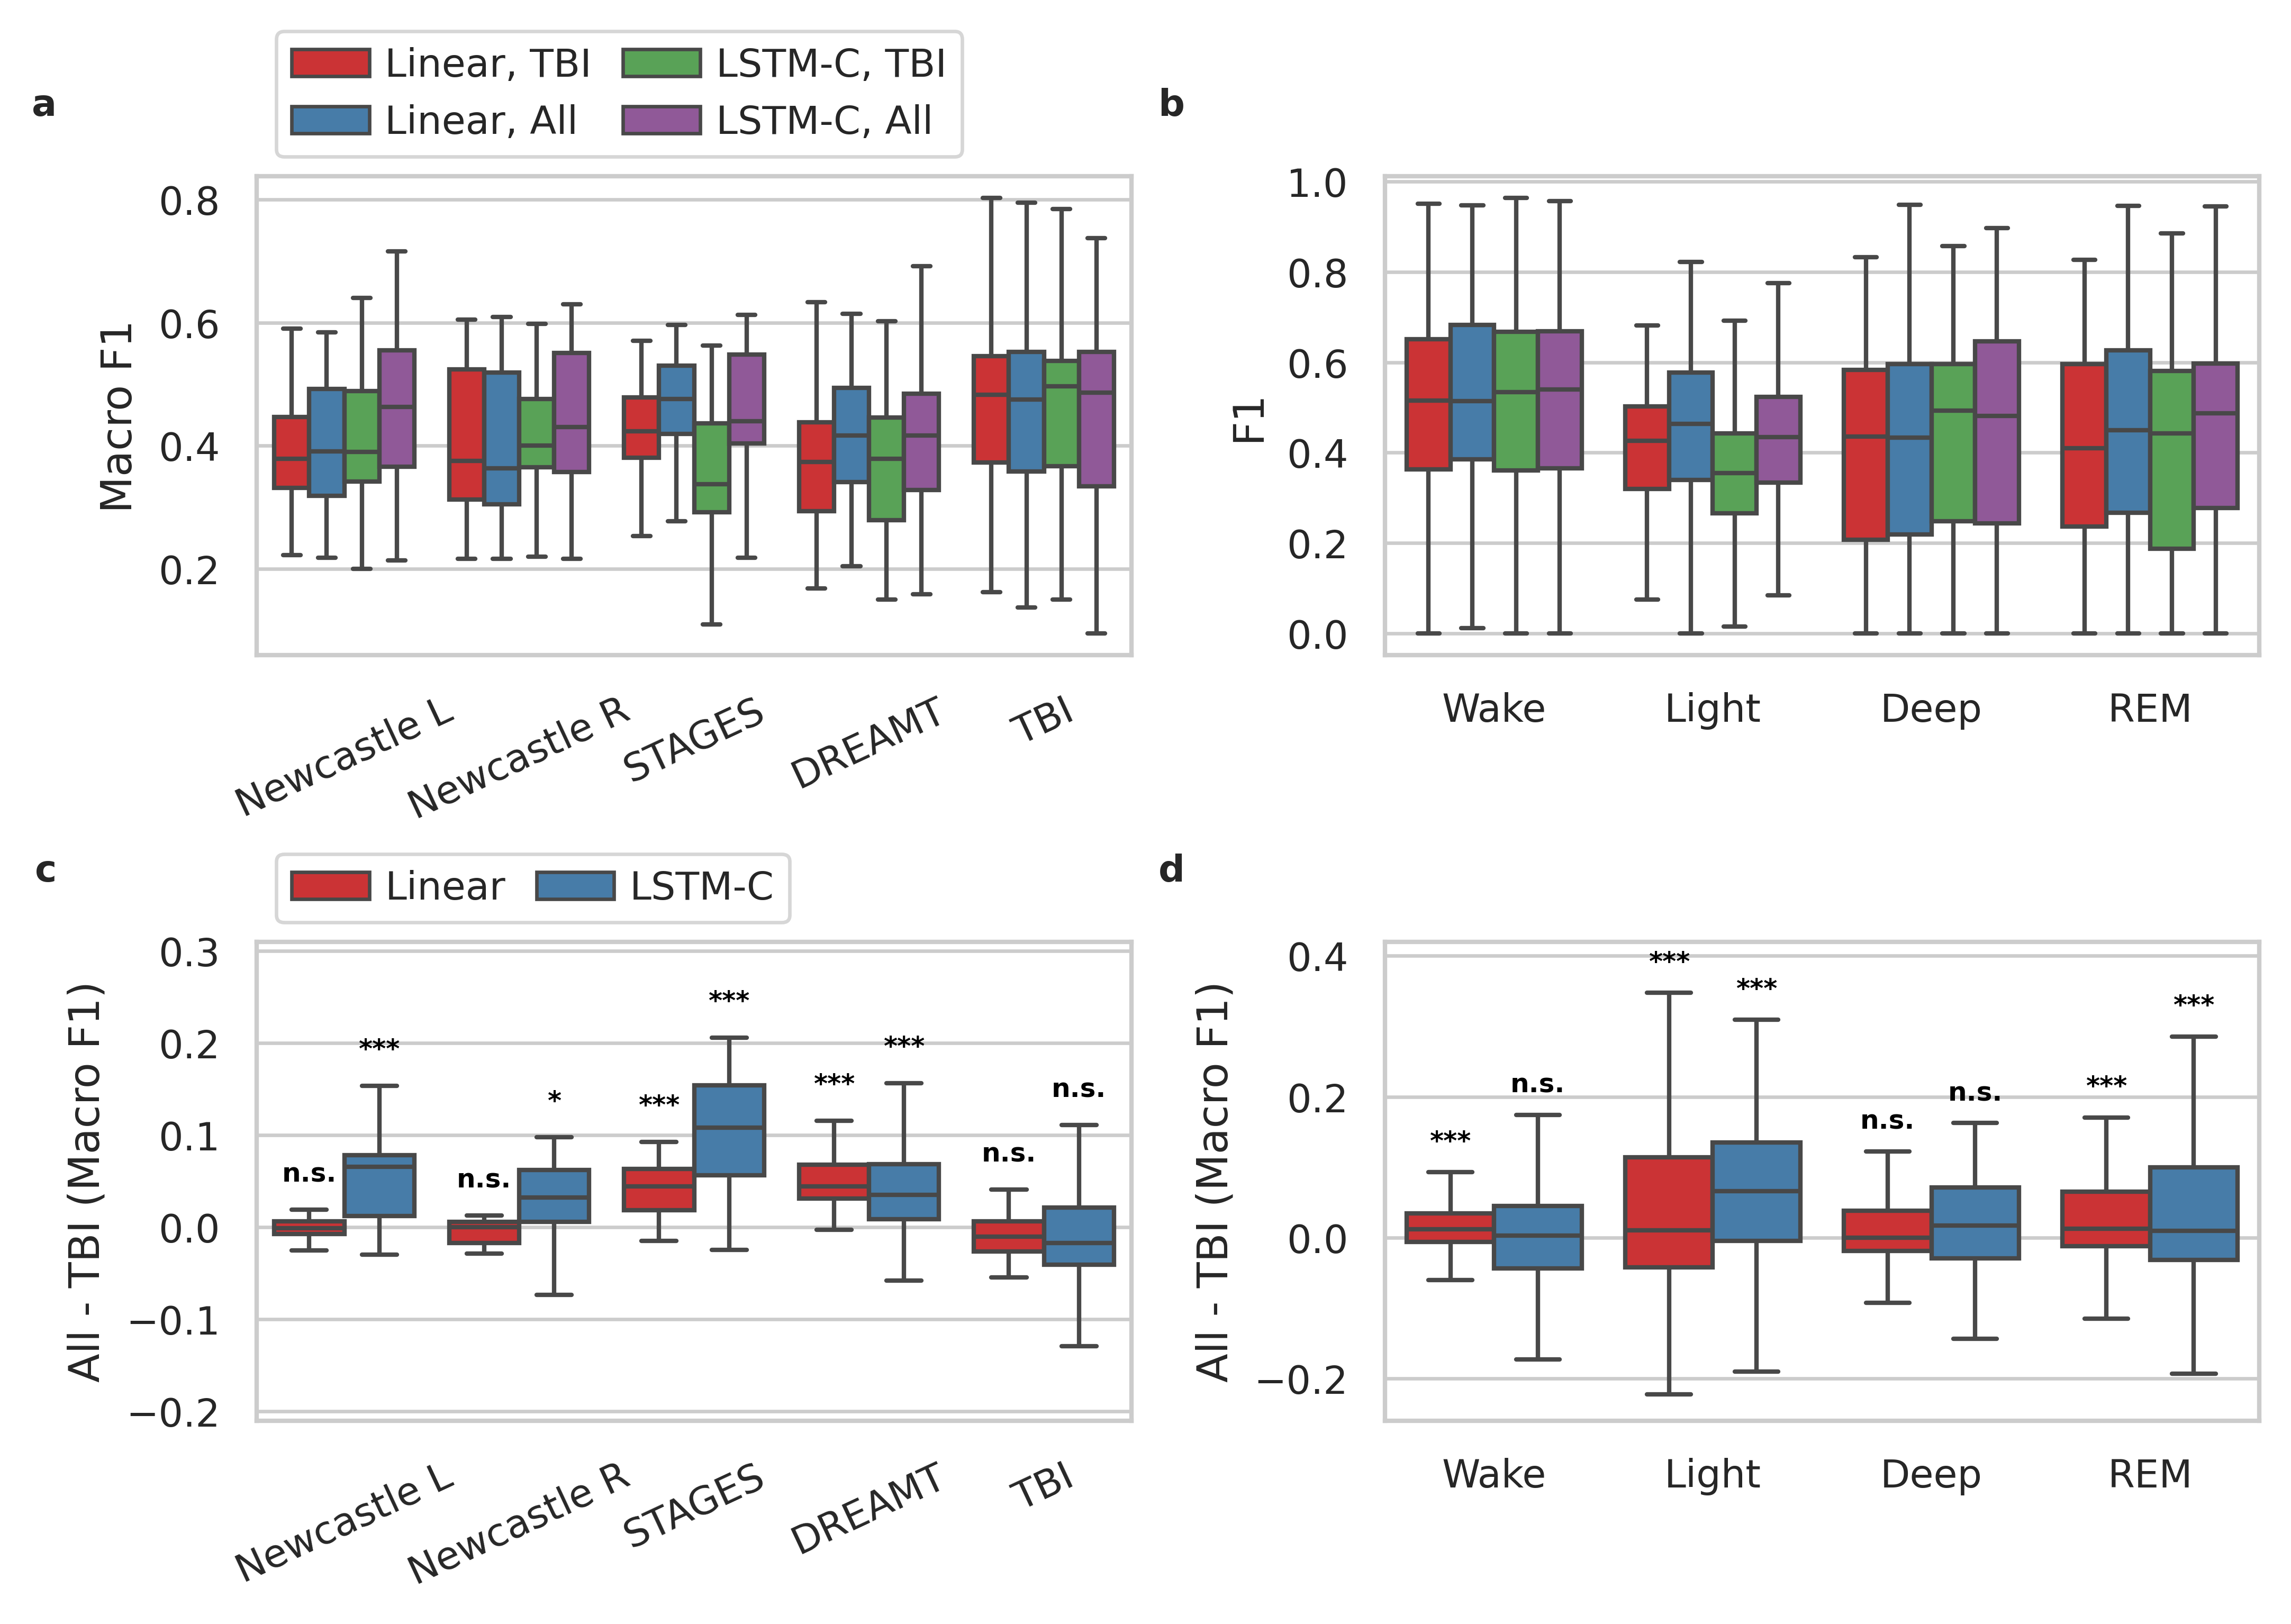

In [117]:
from scipy.stats import ttest_1samp

sns.set_context('paper')
sns.set_style('whitegrid')
matplotlib.rcParams['font.size'] = 7
matplotlib.rcParams['font.family'] = 'sans-serif'

metric = 'F1'
cw_df = cw_f1s.copy()
cw_df['dataset'] = dataset_i
cw_df['finetuning'] = exp_i
cw_df['dataset'] = cw_df['dataset'].map(dset_map)
cw_df = cw_df.rename(columns=ss_case_map)

macro_new = macro_results.copy()
macro_new['dataset'] = dataset_i
macro_new['finetuning'] = exp_i
macro_new['dataset'] = macro_new['dataset'].map(dset_map)

macro_diff = macro_new.copy()
macro_diff['subject'] = subject_i
macro_diff = macro_diff.set_index(['finetuning', 'dataset', 'subject'])
linear_diff = macro_diff.loc['Linear, Full Internal'] - macro_diff.loc['Linear, TBI Only']
linear_diff['finetuning'] = 'Linear'
lstmc_diff = macro_diff.loc['LSTM-C, Full Internal'] - macro_diff.loc['LSTM-C, TBI Only']
lstmc_diff['finetuning'] = 'LSTM-C'
macro_diff = pd.concat([linear_diff, lstmc_diff]).reset_index('dataset')

macro_pval = {}
for dataset in macro_diff.dataset.unique():
    rows = np.logical_and(macro_diff['dataset']==dataset, macro_diff['finetuning']=='Linear')
    res = ttest_1samp(macro_diff.loc[rows, 'F1'], popmean=0, nan_policy='omit')
    macro_pval[f'Linear, {dataset}'] = res[1]

    rows = np.logical_and(macro_diff['dataset']==dataset, macro_diff['finetuning']=='LSTM-C')
    res = ttest_1samp(macro_diff.loc[rows, 'F1'], popmean=0, nan_policy='omit')
    macro_pval[f'LSTM-C, {dataset}'] = res[1]

cw_diff = cw_df.copy()
cw_diff['subject'] = subject_i
cw_diff = cw_diff.set_index(['finetuning', 'dataset', 'subject'])
cw_linear_diff = cw_diff.loc['Linear, Full Internal'] - cw_diff.loc['Linear, TBI Only']
cw_linear_diff['finetuning'] = 'Linear'
cw_lstmc_diff = cw_diff.loc['LSTM-C, Full Internal'] - cw_diff.loc['LSTM-C, TBI Only']
cw_lstmc_diff['finetuning'] = 'LSTM-C'
cw_diff = pd.concat([cw_linear_diff, cw_lstmc_diff]).reset_index('dataset')

cw_pval = {}
for stage in ['Deep','Light','REM','Wake']:
    rows = cw_diff['finetuning']=='Linear'
    res = ttest_1samp(cw_diff.loc[rows, stage], popmean=0, nan_policy='omit')
    cw_pval[f'Linear, {stage}'] = res[1]

    rows = cw_diff['finetuning']=='LSTM-C'
    res = ttest_1samp(cw_diff.loc[rows, stage], popmean=0, nan_policy='omit')
    cw_pval[f'LSTM-C, {stage}'] = res[1]

fig, axes = plt.subplots(2,2, dpi=600, figsize=(7.1,5), layout='constrained')
axes = axes.ravel()
# dset_macro = macro_new.loc[macro_new['dataset'] == dset_order[i]]
macro_new['finetuning'] = macro_new['finetuning'].map({
    'Linear, Full Internal': 'Linear, All',
    'LSTM-C, Full Internal': 'LSTM-C, All',
    'Linear, TBI Only': 'Linear, TBI',
    'LSTM-C, TBI Only': 'LSTM-C, TBI',
})
ax = sns.boxplot(
    macro_new.melt(id_vars=['dataset', 'finetuning'], value_vars=[metric]), 
    x='dataset', y='value', hue='finetuning', 
    palette='Set1', ax=axes[0], legend=True, showfliers=False, 
    order = ['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI'],
)
ax.tick_params('x', rotation=25)
ax.set_ylabel(f'Macro {metric}')
ax.set_xlabel('')
ax.legend(title='', ncols=2, handletextpad = 0.4, columnspacing=0.8,  bbox_to_anchor=(-0.0,1.), loc='lower left')

ax = sns.boxplot(
    macro_diff.melt(id_vars=['dataset', 'finetuning'], value_vars=[metric]), 
    x='dataset', y='value', hue='finetuning', 
    palette='Set1', ax=axes[2], legend=True, showfliers=False, 
    order = ['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI'],
)
ax.tick_params('x', rotation=25)
ax.set_ylabel(f'All - TBI (Macro {metric})')
ax.set_xlabel('')
ax.legend(title='', ncols=2, handletextpad = 0.4, columnspacing=0.8,  bbox_to_anchor=(-0.0,1.), loc='lower left')

## Add starts
def whisker_bounds(values):
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    # whiskers are the min/max inside the bounds
    lower_whisker = np.min(values[values >= lower])
    upper_whisker = np.max(values[values <= upper])
    return lower_whisker, upper_whisker

def p_to_star(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    else: return 'n.s.'  # optional

for k, ft in enumerate(['Linear', 'LSTM-C']):
    for i, dataset in enumerate(['Newcastle L','Newcastle R','STAGES','DREAMT','TBI']):
        p = macro_pval.get(f'{ft}, {dataset}', None)
        if p is None:
            continue
        star = p_to_star(p)

        # Find max y-value for that dataset to place annotation above
        rows = np.logical_and(macro_diff['dataset']==dataset, macro_diff['finetuning'] == ft)
        data_y = macro_diff.loc[rows, metric]
        _, y = whisker_bounds(data_y)
        x = i + 0.2 if k == 1 else i - 0.2
        ax.text(x, y + 0.025, star, ha='center', va='bottom', fontsize=6, color='black', fontweight='bold')
ax.set_ylim(-0.21,0.31)
###

ax = sns.boxplot(
    cw_df.melt(id_vars=['dataset', 'finetuning']), x='variable', y='value',
    hue='finetuning', palette='Set1', ax=axes[1], legend=False, showfliers=False, 
    order = ['Wake', 'Light', 'Deep', 'REM'],
)
ax.set_ylabel(metric)
ax.set_xlabel('')

ax = sns.boxplot(
    cw_diff.melt(id_vars=['dataset', 'finetuning']), x='variable', y='value',
    hue='finetuning', palette='Set1', ax=axes[3], legend=False, showfliers=False, 
    order = ['Wake', 'Light', 'Deep', 'REM'],
)
ax.set_ylabel(f'All - TBI (Macro {metric})')
ax.set_xlabel('')

for k, ft in enumerate(['Linear', 'LSTM-C']):
    for i, stage in enumerate(['Wake', 'Light', 'Deep', 'REM']):
        p = cw_pval.get(f'{ft}, {stage}', None)
        if p is None:
            continue
        star = p_to_star(p)

        # Find max y-value for that stage to place annotation above
        rows = cw_diff['finetuning'] == ft
        data_y = cw_diff.loc[rows, stage]
        _, y = whisker_bounds(data_y)
        x = i + 0.2 if k == 1 else i - 0.2
        ax.text(x, y+0.025, star, ha='center', va='bottom', fontsize=6, color='black', fontweight='bold')
ax.set_ylim(-0.26,0.42)

for i, ax in enumerate(axes.ravel()):
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.25, 1.15), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize', fontweight = 'bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )

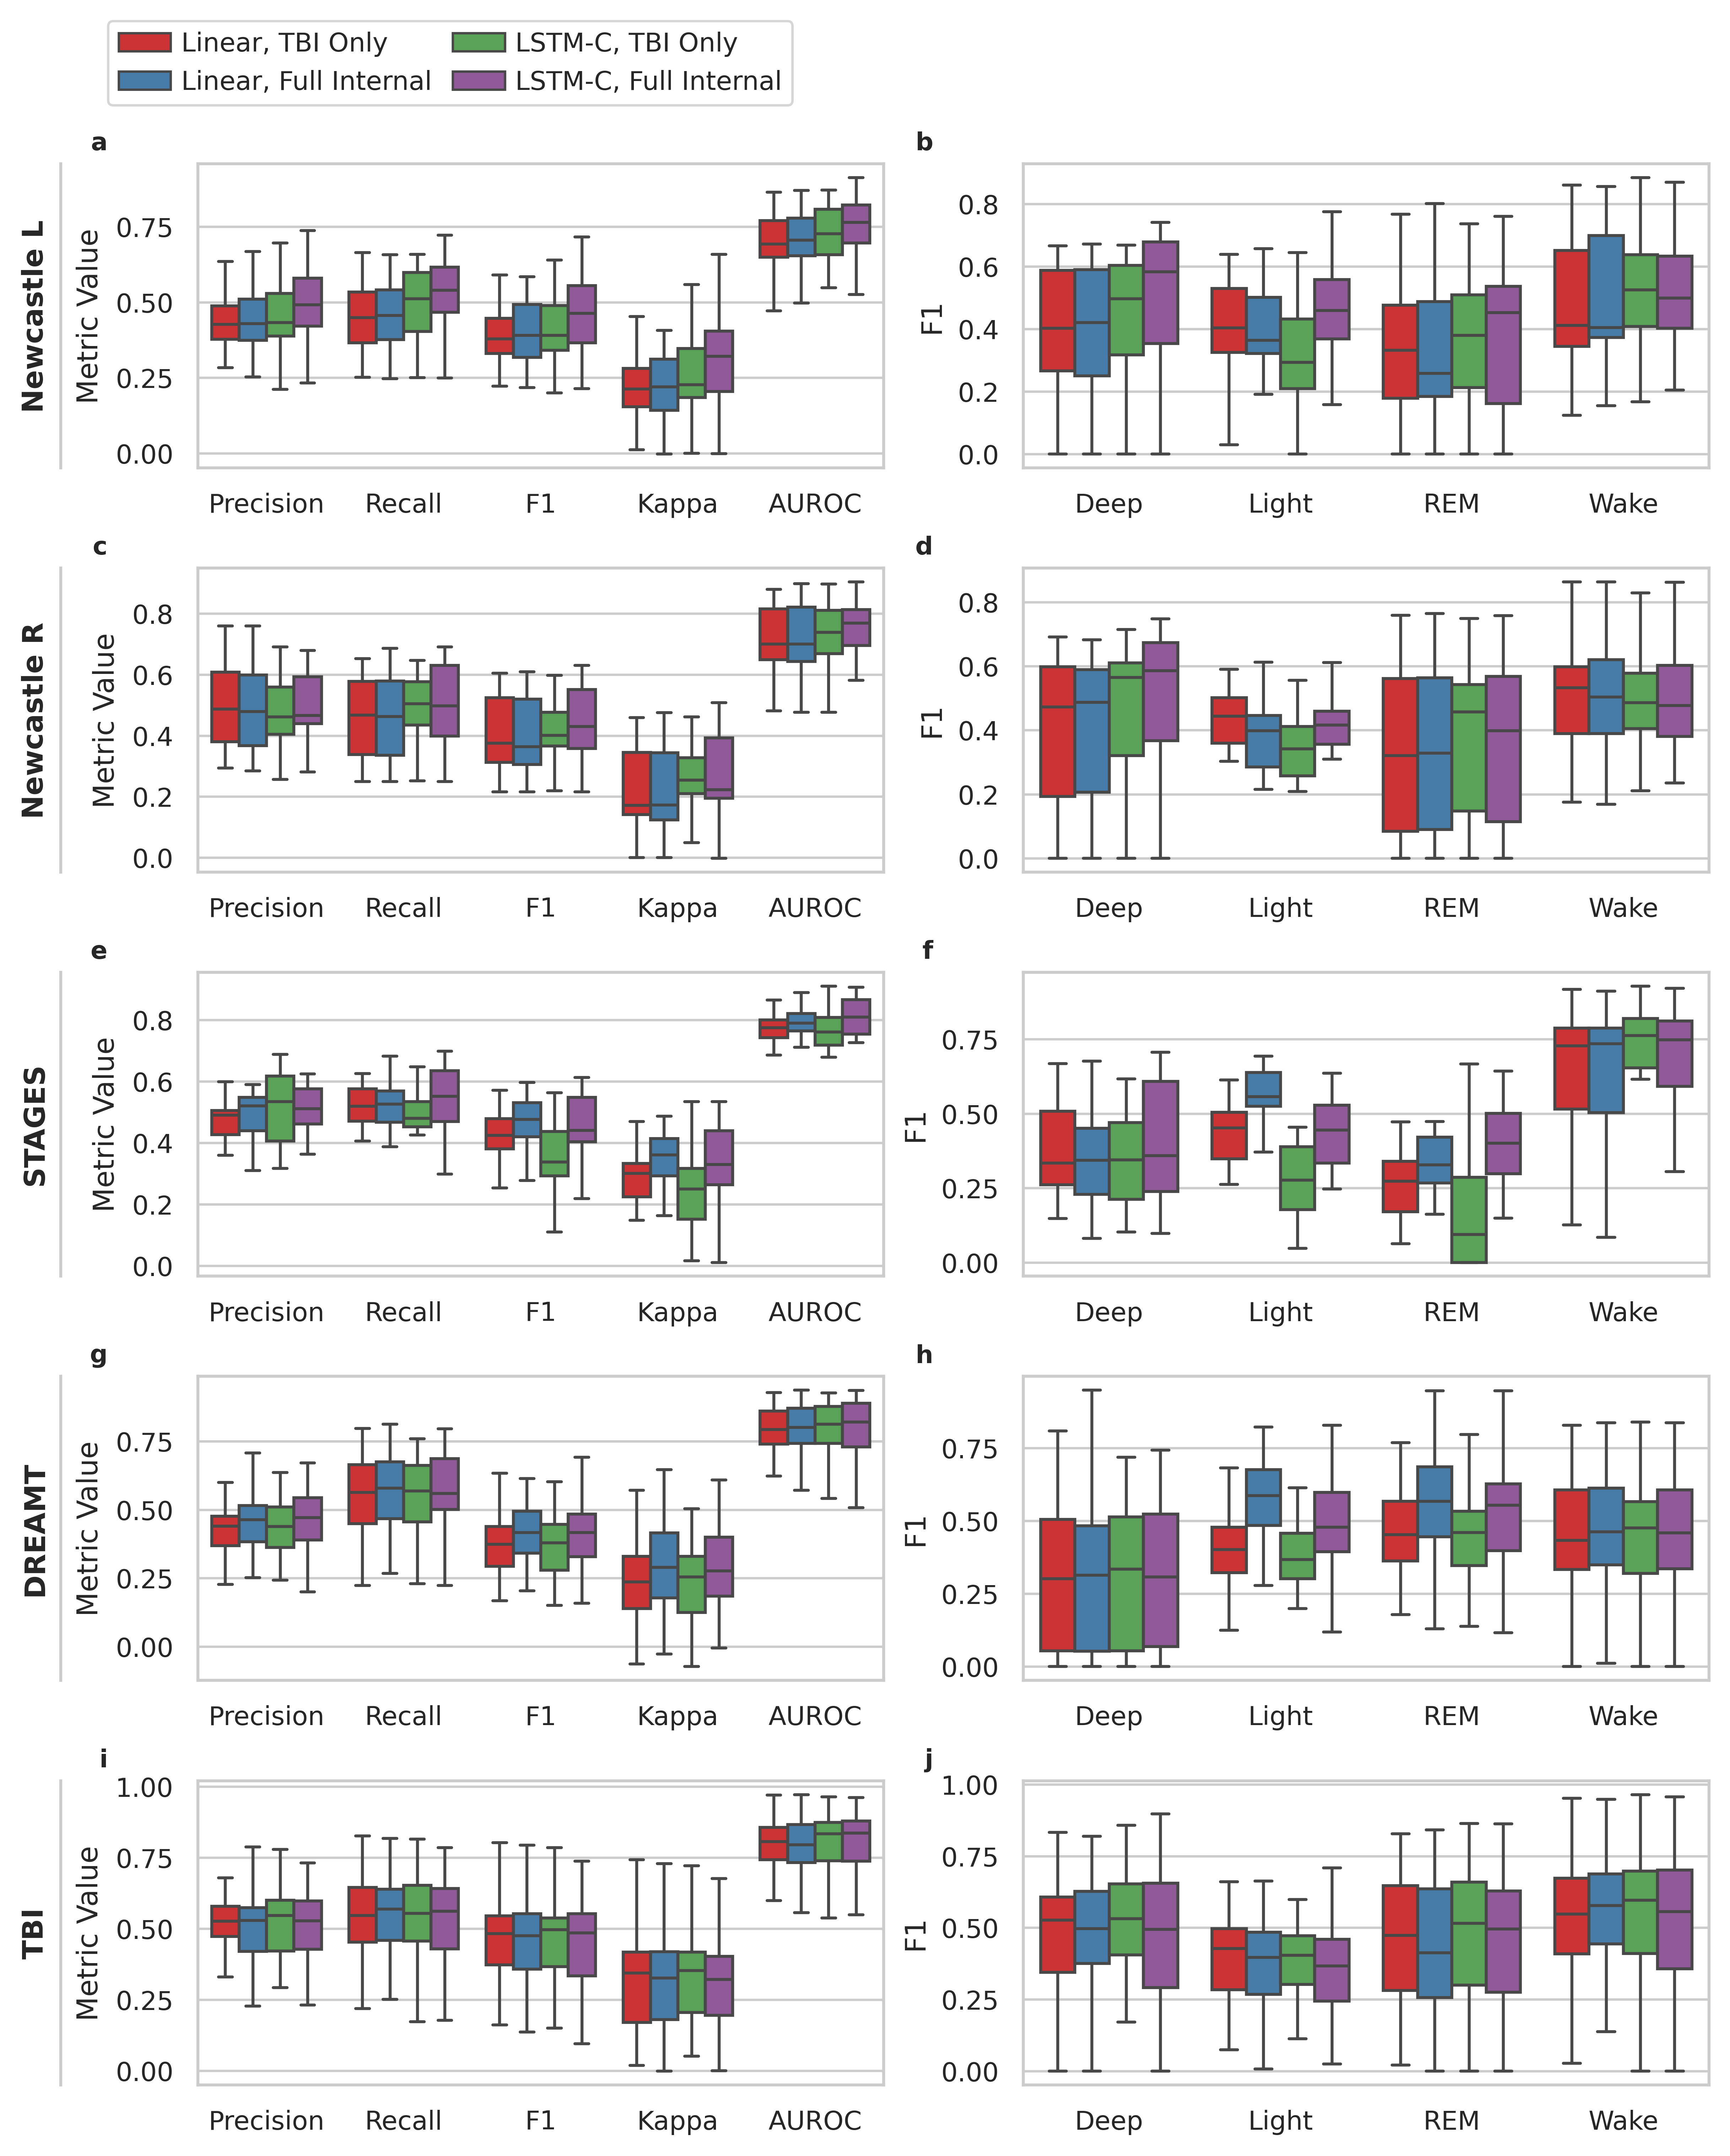

In [15]:
# Make 5-by-2 plot with dataset on rows, macro performances on the lest and cw AUC on right cols
cw_auc_new = cw_aucs.copy()
cw_df = cw_f1s.copy()
cw_df['dataset'] = dataset_i
cw_df['finetuning'] = exp_i
cw_df['dataset'] = cw_df['dataset'].map(dset_map)
cw_df = cw_df.rename(columns=ss_case_map)

macro_new = macro_results.copy()
macro_new['dataset'] = dataset_i
macro_new['finetuning'] = exp_i
macro_new['dataset'] = macro_new['dataset'].map(dset_map)

fig, axes = plt.subplots(5,2, dpi=600, figsize=(8,10), layout='constrained')

for i, ax in enumerate(axes):
    dset_macro = macro_new.loc[macro_new['dataset'] == dset_order[i]]
    sns.boxplot(
        dset_macro.melt(id_vars=['dataset', 'finetuning']), x='variable', y='value',
        hue='finetuning', palette='Set1', ax=ax[0], legend=i==0, showfliers=False, 
        order = ['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI'],
        # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
    )
    sec = ax[0].secondary_yaxis(location=-0.2)
    sec.set_ylabel(f'{dset_order[i]}', fontweight='bold')
    sec.set_yticks([],[])
    ax[0].set_ylabel('Metric Value')
    ax[0].set_xlabel('')
    if i == 0:
        ax[0].legend(title='', ncols=2, handletextpad = 0.4, columnspacing=0.8,  bbox_to_anchor=(-0.15,1.15), loc='lower left')

    dset_cw_df = cw_df.loc[cw_df['dataset'] == dset_order[i]]
    sns.boxplot(
        dset_cw_df.melt(id_vars=['dataset', 'finetuning']), x='variable', y='value',
        hue='finetuning', palette='Set1', ax=ax[1], legend=False, showfliers=False, 
        # order = ss_label_name,
        # hue_order=['Newcastle L', 'Newcastle R', 'STAGES', 'DREAMT', 'TBI']
    )
    ax[1].set_ylabel('F1')
    ax[1].set_xlabel('')

for i, ax in enumerate(axes.ravel()):
    ax.annotate(
        f'{chr(97+i)}',
        xy=(-0.15, 1.07), xycoords='axes fraction',
        xytext=(+0.5, -0.5), textcoords='offset fontsize', fontweight = 'bold',
        fontsize='large', verticalalignment='bottom', horizontalalignment='right',# fontfamily='verdana',
        bbox=dict(facecolor='none', edgecolor='none', pad=3.0)
    )


In [46]:
# Plot Subject-wise class wise scores
cw_f1s['score'] = 'F1'
cw_f1s['dataset'] = dataset_i
cw_f1s['finetuning'] = exp_i

cw_precs['score'] = 'Precision'
cw_precs['dataset'] = dataset_i
cw_precs['finetuning'] = exp_i

cw_recalls['score'] = 'Recall'
cw_recalls['dataset'] = dataset_i
cw_recalls['finetuning'] = exp_i

cw_aucs['score'] = 'AUC'
cw_aucs['dataset'] = dataset_i
cw_aucs['finetuning'] = exp_i

cw_scores = pd.concat([cw_f1s, cw_precs, cw_recalls, cw_aucs], axis=0)
cw_change = cw_scores.loc[cw_scores['finetuning'] == 'TBI Only'] - cw_scores.loc[cw_scores['finetuning'] == 'All Internal']

# cw_scores = cw_scores.melt(id_vars=['score', 'dataset', 'finetuning'], value_vars=['wake', 'light', 'deep', 'rem'])
# cw_scores['variable'] = cw_scores['variable'].map(ss_case_map)

# cw_scores['dataset'] = cw_scores['dataset'].map({
#     'newcastle_left': 'Newcastle L',
#     'newcastle_right': 'Newcastle R',
#     'stages': 'STAGES',
#     'dreamt': 'DREAMT',
#     'tbi': 'TBI',
# })

# metric = 'AUC'
# cw_scores = cw_scores.loc[cw_scores['score']==metric]
# with sns.axes_style('darkgrid'):
#     fig, axes = plt.subplots(3,2, dpi=600, figsize=(7,7), layout='constrained')
#     axes = axes.ravel()
#     ax = sns.boxplot(cw_scores, x='variable', y='value', hue='finetuning', ax=axes[0])
#     ax.set_title('All Internal Test Sets')
#     ax.set_xlabel('')
#     ax.set_ylabel(metric)
#     ax.legend(title='Finetuning Data', ncols=2, bbox_to_anchor = (0,1.15), loc='lower left')
#     for i, dataset in enumerate(cw_scores['dataset'].unique()):
#         ax = sns.boxplot(
#             cw_scores.loc[cw_scores['dataset'] == dataset],
#             x='variable', y='value', hue='finetuning', ax=axes[i+1],
#             legend=False,
#         )
#         ax.set_title(dataset)
#         ax.set_xlabel('')
#         ax.set_ylabel(metric)

